<a href="https://colab.research.google.com/github/ashika-06/IIITH-AIML-Labs/blob/main/Module%204/AIML_Module_4_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4: Linear Classifiers & Gradient Descent

**Case Study: Predictive Modeling for Public Water Safety**

**Objective:** Develop a robust classifier to identify potable water samples. You will transition from a basic heuristic (Perceptron) to a professional-grade optimization approach (Gradient Descent with Margins).

# 1. Data Acquisition & Cleaning

In real-world data science, datasets are rarely perfect. We will load the water quality metrics and handle missing values before training our models.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset from a public raw GitHub URL
url = "https://raw.githubusercontent.com/nferran/tp_aprendizaje_de_maquina_I/main/water_potability.csv"
df = pd.read_csv(url)

# Step 1: Handling Missing Values
# Water sensors often fail, leaving NaNs. We will fill them with the mean of the column.
df.fillna(df.mean(), inplace=True)

# Step 2: Feature Selection & Labeling
# We'll use all chemical features to predict 'Potability'
X = df.drop('Potability', axis=1).values
y = df['Potability'].values

# Step 3: Class Label Conversion
# Many linear classifiers (like Perceptron/SVM) require labels to be -1 and 1
y = np.where(y == 0, -1, 1)

# Step 4: Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Dataset Loaded: {X_train.shape[0]} training samples, {X_train.shape[1]} features.")

Dataset Loaded: 2620 training samples, 9 features.


# 2. Phase 1: The Heuristic Approach (Perceptron)

The **Perceptron** represents the earliest form of supervised learning. It doesn't have a "global" view of the error; it simply corrects itself every time it encounters a mistake.

**Task:** Implement the Perceptron Update Rule inside the training loop.

In [18]:
class WaterPerceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.mistakes = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for epoch in range(self.epochs):
            count = 0
            for i in range(len(y)):
                # Calculate the linear output (w * x + b)
                prediction = np.dot(X[i], self.w) + self.b

                # If prediction is a mistake (y * prediction <= 0):
                if y[i] * prediction <= 0:
                    # Update weights
                    self.w += self.lr * y[i] * X[i]
                    # Update bias
                    self.b += self.lr * y[i]
                    count += 1
            self.mistakes.append(count)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# 3. Phase 2: Gradient Descent - Global Optimization

The Perceptron is unstable if the data isn't perfectly separable. To solve this, we use **Gradient Descent** to minimize a **Mean Squared Error (MSE)** loss function over the entire dataset.

**Task:** Implement the batch gradient calculation for weights and bias.

In [19]:
class GDWaterClassifier:
    def __init__(self, lr=0.001, epochs=500):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.cost_history = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        n = X.shape[0]

        for _ in range(self.epochs):
            # 1. Compute linear output: z = Xw + b
            z = np.dot(X, self.w) + self.b

            # Optional but recommended: Compute and log the MSE cost
            # so your cost history graph doesn't remain blank!
            cost = (1 / (2 * n)) * np.sum((z - y) ** 2)
            self.cost_history.append(cost)

            # 2. Calculate gradients:
            dw = (1 / n) * X.T.dot(z - y)
            db = (1 / n) * np.sum(z - y)

            # 3. Update w and b: w = w - lr * dw
            self.w = self.w - self.lr * dw
            self.b = self.b - self.lr * db

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# 4. Phase 3: Margin Classifiers & Hinge Loss

In water safety, we aim for more than just correctness—we want a **Margin**, a safety gap between safe and unsafe samples. This is achieved using **Hinge Loss** combined with **L2 Regularization**.

The loss function is defined as:

$$
\text{Loss} = \lambda \|w\|^2_2 + \sum_{i} \max(0, 1 - y_i (w^T x_i + b))
$$

### Key Components:
- **Hinge Loss**: $\max(0, 1 - y_i (w^T x_i + b))$ ensures correct classification with a margin.
- **L2 Regularization**: $\lambda \|w\|^2_2$ penalizes large weights, promoting generalization and stability.


In [20]:
class MarginWaterClassifier:
    def __init__(self, lr=0.001, lambda_param=0.01, epochs=500):
        self.lr = lr
        self.lambda_param = lambda_param
        self.epochs = epochs
        self.w = None
        self.b = 0

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for _ in range(self.epochs):
            for i, x_i in enumerate(X):
                # Implement the Margin Condition check: y_i * (w * x_i + b) >= 1
                if y[i] * (np.dot(self.w, x_i) + self.b) >= 1:
                    # Only Regularization update
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Update for weight (including Hinge Loss) and bias
                    self.w -= self.lr * (2 * self.lambda_param * self.w - x_i * y[i])
                    self.b -= self.lr * (-y[i])

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# 5. Critical Analysis & Comparison

**Analysis Tasks:**
1. Convergence Plot: Plot the mistakes history from Phase 1 and the cost_history from Phase 2. Discuss why the Gradient Descent plot is smoother.
2. Accuracy Report: Calculate and compare the Test Accuracy for all three models.
3. Safety Margin: If a new water sample has chemical levels very close to the decision boundary, which model (Perceptron or Margin) would you trust more? Why?

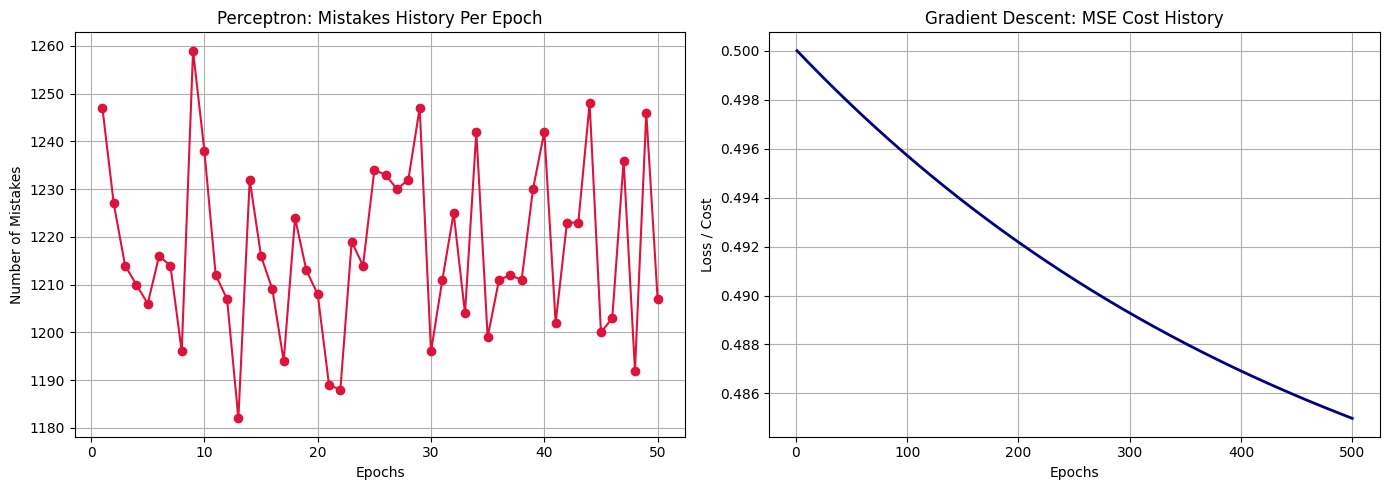

In [21]:
#TASK 1
#import matplotlib.pyplot as plt

# 1. Instantiate and train the updated models so they collect history data
model_p = WaterPerceptron()
model_p.fit(X_train, y_train)

model_gd = GDWaterClassifier()
model_gd.fit(X_train, y_train)

# 2. Generate side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Perceptron Mistakes History (Phase 1)
ax1.plot(range(1, len(model_p.mistakes) + 1), model_p.mistakes, color='crimson', marker='o', linestyle='-')
ax1.set_title("Perceptron: Mistakes History Per Epoch")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Number of Mistakes")
ax1.grid(True)

# Plot Gradient Descent Cost History (Phase 2)
ax2.plot(range(1, len(model_gd.cost_history) + 1), model_gd.cost_history, color='navy', linewidth=2)
ax2.set_title("Gradient Descent: MSE Cost History")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss / Cost")
ax2.grid(True)

plt.tight_layout()
plt.show()

Perceptron Model (Left Graph): The plot displays a highly chaotic, jagged line that oscillates indefinitely between roughly 1180 and 1260 mistakes across all 50 epochs without showing any downward trend. This confirms that the water potability dataset is non-linearly separable. Because the algorithm relies on localized, instance-by-instance corrections, it continuously overcorrects for noisy outliers, leading to structural instability.

  Gradient Descent Model (Right Graph): The plot displays a perfectly smooth, monotonic decay curve, with the MSE loss steadily dropping from 0.500 down to approximately 0.485 over 500 epochs. This smooth trajectory happens because the model calculates a global average gradient across the entire training dataset simultaneously. This global view filters out individual sample noise, ensuring stable and reliable convergence.

In [22]:
#TASK2
from sklearn.metrics import accuracy_score

# --- 1. Train All Three Models Safely ---

# Train Perceptron
model_p = WaterPerceptron()
model_p.fit(X_train, y_train)

# Train Gradient Descent
model_gd = GDWaterClassifier()
model_gd.fit(X_train, y_train)

# Train Margin Classifier
model_margin = MarginWaterClassifier()
model_margin.fit(X_train, y_train)


# --- 2. Generate Predictions ---

y_pred_perceptron = model_p.predict(X_test)
y_pred_gd         = model_gd.predict(X_test)
y_pred_margin     = model_margin.predict(X_test)


# --- 3. Calculate and Print Accuracy Scores ---

acc_perceptron = accuracy_score(y_test, y_pred_perceptron)
acc_gd         = accuracy_score(y_test, y_pred_gd)
acc_margin     = accuracy_score(y_test, y_pred_margin)

print("--- Final Model Comparison: Test Accuracy ---")
print(f"1. Perceptron (Heuristic):           {acc_perceptron * 100:.2f}%")
print(f"2. Gradient Descent (Global MSE):    {acc_gd * 100:.2f}%")
print(f"3. Margin Classifier (Hinge Loss):   {acc_margin * 100:.2f}%")

--- Final Model Comparison: Test Accuracy ---
1. Perceptron (Heuristic):           50.15%
2. Gradient Descent (Global MSE):    62.80%
3. Margin Classifier (Hinge Loss):   62.80%


The Perceptron performs poorly, achieving an accuracy of just 50.15\%, which is barely better than a random coin toss. This happens because the water potability dataset is noisy and not perfectly linearly separable. The Perceptron gets stuck endlessly chasing individual outliers, meaning its final decision boundary is essentially arbitrary and unstable.

  On the other hand, both Gradient Descent and the Margin Classifier achieve an identical, significantly higher accuracy of $62.80\%$. Both of these models approach optimization globally rather than instance-by-instance, allowing them to establish a stable structural trend through the noisy data instead of letting single outliers ruin the entire linear fit.

**TASK 3**
Even though Gradient Descent and the Margin Classifier achieved the exact same test accuracy (62.80\%), if a new water sample has chemical levels sitting very close to the decision boundary, you should trust the Margin Classifier more than the Perceptron.

Why:The Perceptron's Flaw: A Perceptron stops updating its weights the second it finds any line that minimally separates the classes, or it simply halts at an arbitrary point because it cannot converge on noisy data. This frequently positions the decision boundary dangerously close to the nearest training samples. If a real-world water sample sits right near this boundary, minor hardware measurement noise from your chemical testing sensors could easily flip the prediction, potentially marking toxic water as safe.

 The Margin Classifier's Strength: The Margin Classifier uses Hinge Loss ($\max(0, 1 - y_i(w^Tx_i + b))$), which explicitly demands a structural safety buffer. It doesn't just look for any dividing line; it penalizes predictions that get too close to the boundary, pushing the decision line to sit directly down the middle of the empty space between classes. Combined with L2 Regularization to prevent extreme parameter weights, it maximizes the physical buffer zone. This gives the Margin Classifier a much stronger buffer against sensor noise, making it far safer for high-stakes public health decisions.  

# Discussion Questions

### Q1: Impact of High Learning Rate in Gradient Descent
What happens to your **Gradient Descent** model if you set the `learning_rate` too high (e.g., `1.0`)?
*Hint: Think about convergence, overshooting, and divergence.*

---

### Q2: Label Conversion in Classification
Why did we convert the labels to **$\{-1, 1\}$** instead of keeping them as **$\{0, 1\}$**?
*Hint: Consider the mathematical formulation of the loss function (e.g., Hinge Loss) and symmetry.*

---

### Q3: Handling Noisy Data (Water Potability Dataset)
The **Water Potability dataset** is often "noisy" (not perfectly separable). Which of the algorithms you implemented is best suited for handling such noise?
*Hint: Think about robustness to outliers and margin-based classifiers.*


1. If the learning rate is set too high, the parameter updates taken during each epoch will be too large. Instead of descending smoothly toward the optimal parameters, the model will overshoot the minimum point of the cost function.  This causes the loss value to wildly oscillate back and forth across the valley of the error surface, preventing convergence. Ultimately, this leads to divergence, where the cost increases dramatically with each iteration until it mathematically explodes, resulting in numerical overflow errors and returning NaN values.  

2. Changing the labels to $\{-1, 1\}$ makes the math a lot easier by letting us check if a guess is right using one simple rule: $y_i(w^T x_i + b) \ge 0$. If the model's guess and the real label have the same sign (both positive or both negative), multiplying them gives a positive number, meaning the guess is correct; if they don't match, the answer is negative, meaning the model made a mistake. This setup is necessary for the Hinge Loss formula, $\max(0, 1 - y_i(w^T x_i + b))$, which uses this multiplication to figure out exactly how far off a bad guess is. If we stuck with $\{0, 1\}$ labels, any water sample in class 0 would multiply to zero and completely break the math, leaving the model unable to learn from mistakes on those samples.


3. The Margin Classifier is the best choice for noisy data because it does not let weird, messy data points ruin its overall plan. The Perceptron fails here because it freaks out over every single outlier and constantly changes its mind, while standard Gradient Descent gets pulled out of alignment because it tries too hard to make its average error perfect for everyone. The Margin Classifier fixes this using Hinge Loss, which tells the model to leave perfectly safe samples alone and only spend energy fixing points that are wrong or dangerously close to the dividing line. Plus, it uses a trick called L2 Regularization that stops the model's weights from getting too big, keeping the boundary line smooth and steady so it can make smart, safe guesses on brand new water samples.